# Day-41(2July)
### Sales Data Analysis for Retail Store using Statistical Approach

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
np.random.seed(42)
data={
    "product_id":range(1,21),
    "product_name":[f"product{i}" for i in range(1,21)],
    "category": np.random.choice(["Electronics","Clothings","Home","Sports"],20),
    "units_sold": np.random.poisson(lam=20, size=20),
    "sale_date":pd.date_range(start="2025-01-01",periods=20,freq="D")
}
sales_data=pd.DataFrame(data)
print("Sales Data :\n",sales_data)

Sales Data :
     product_id product_name     category  units_sold  sale_date
0            1     product1         Home          25 2025-01-01
1            2     product2       Sports          15 2025-01-02
2            3     product3  Electronics          17 2025-01-03
3            4     product4         Home          19 2025-01-04
4            5     product5         Home          21 2025-01-05
5            6     product6       Sports          17 2025-01-06
6            7     product7  Electronics          19 2025-01-07
7            8     product8  Electronics          16 2025-01-08
8            9     product9         Home          21 2025-01-09
9           10    product10    Clothings          21 2025-01-10
10          11    product11         Home          17 2025-01-11
11          12    product12         Home          22 2025-01-12
12          13    product13         Home          14 2025-01-13
13          14    product14         Home          17 2025-01-14
14          15    product1

### Descriptive Statistics 

In [3]:
print("Descriptive Stats on units_sold :\n",sales_data["units_sold"].describe())

Descriptive Stats on units_sold :
 count    20.000000
mean     18.800000
std       3.302312
min      13.000000
25%      17.000000
50%      18.500000
75%      21.000000
max      25.000000
Name: units_sold, dtype: float64


In [4]:
mean_sales=sales_data["units_sold"].mean()
median_sales=sales_data["units_sold"].median()
mode_sales=sales_data["units_sold"].mode()[0]
variance_sales=sales_data["units_sold"].var()
std_sales=sales_data["units_sold"].std()
# f-stings
print(f"Mean units_sold are : {mean_sales}")
print(f"Median of units_sold is : {median_sales}")
print(f"Mode of units_sold are : {mode_sales}")
print(f"Variance of units_sold are : {variance_sales}")
print(f"Standard Deviation of units_sold are : {std_sales}")

Mean units_sold are : 18.8
Median of units_sold is : 18.5
Mode of units_sold are : 17
Variance of units_sold are : 10.90526315789474
Standard Deviation of units_sold are : 3.3023117899275864


In [5]:
sales_data["units_sold"].value_counts()

units_sold
17    5
21    5
25    2
19    2
15    1
16    1
22    1
14    1
13    1
18    1
Name: count, dtype: int64

In [6]:
# Group by category and calculate total and average sales
category_stats=sales_data.groupby("category")["units_sold"].agg(["sum","mean","std"]).reset_index()
category_stats

,category,sum,mean,std
0,Clothings,21,21.000000,NaN
1,Electronics,73,18.250000,2.217356
2,Home,181,20.111111,3.723051
3,Sports,101,16.833333,2.714160


In [7]:
category_stats=sales_data.groupby("category")["units_sold"].agg(["sum","mean","std"]).reset_index()
category_stats.columns=["Category","Total Sum","Average of units_sold","Std of units_sold"]
print("Category Statistics:\n",category_stats)

Category Statistics:
       Category  Total Sum  Average of units_sold  Std of units_sold
0    Clothings         21              21.000000                NaN
1  Electronics         73              18.250000           2.217356
2         Home        181              20.111111           3.723051
3       Sports        101              16.833333           2.714160


### Inferencial Statistics
#### 95% Confidence Interval for Mean

In [8]:
confidence_level=0.95
degrees_freedom=len(sales_data["units_sold"])-1
print("degrees_freedom: ",degrees_freedom)
sample_mean= mean_sales
sample_std_error=std_sales/np.sqrt(len(sales_data["units_sold"]))
print("sample_std_error: ",sample_std_error)

degrees_freedom:  19
sample_std_error:  0.7384193645177088


In [9]:
# t-score for Confidence Interval because data is less than 30
t_score = stats.t.ppf((1 + confidence_level) / 2, degrees_freedom)
margin_of_error=sample_std_error*t_score
print("t-score: ",t_score)
print("Margin of Error: ",margin_of_error)

t-score:  2.093024054408263
Margin of Error:  1.545529492176428


In [10]:
confidence_interval=(sample_mean-margin_of_error,sample_mean+margin_of_error)
print("Confidence Interval for Mean of Units Sold : ")
print(confidence_interval)

Confidence Interval for Mean of Units Sold : 
(17.254470507823573, 20.34552949217643)


#### 99% Confidence Interval for Mean

In [11]:
confidence_level=0.99
degrees_freedom=len(sales_data["units_sold"])-1
print("degrees_freedom: ",degrees_freedom)
sample_mean= mean_sales
sample_std_error=std_sales/np.sqrt(len(sales_data["units_sold"]))
print("sample_std_error: ",sample_std_error)
t_score = stats.t.ppf((1 + confidence_level) / 2, degrees_freedom)
margin_of_error=sample_std_error*t_score
print("t-score: ",t_score)
print("Margin of Error: ",margin_of_error)
confidence_interval=(sample_mean-margin_of_error,sample_mean+margin_of_error)
print("Confidence Interval for Mean of Units Sold : ")
print(confidence_interval)

degrees_freedom:  19
sample_std_error:  0.7384193645177088
t-score:  2.860934606449914
Margin of Error:  2.112569514021467
Confidence Interval for Mean of Units Sold : 
(16.687430485978535, 20.912569514021467)


### Hypothesis Testing

In [23]:
t_statistic, p_value = stats.ttest_1samp(sales_data['units_sold'], 20)

print("\nHypothesis Testing (t-test):")
print(f"T-statistic: {t_statistic}, P-value: {p_value}")

if p_value < 0.05:
    print("Reject the null hypothesis: The mean units sold is significantly different from 20.")
else:
    print("Fail to reject the null hypothesis: The mean units sold is not significantly different from 20.")


Hypothesis Testing (t-test):
T-statistic: -1.6250928099424466, P-value: 0.12061572226781002
Fail to reject the null hypothesis: The mean units sold is not significantly different from 20.


### Visualizing the dataset

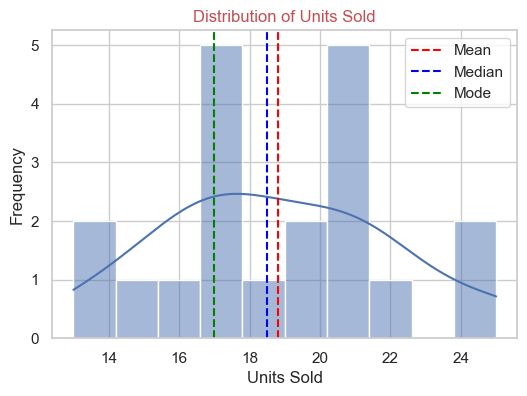

In [17]:
sns.set(style="whitegrid")

# Plot distribution of units sold
plt.figure(figsize=(6,4))
sns.histplot(sales_data['units_sold'], bins=10, kde=True)
plt.title('Distribution of Units Sold',c="r")
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.axvline(mean_sales, color='red', linestyle='--', label='Mean')
plt.axvline(median_sales, color='blue', linestyle='--', label='Median')
plt.axvline(mode_sales, color='green', linestyle='--', label='Mode')
plt.legend()
plt.show()

Text(0, 0.5, 'Units Sold')

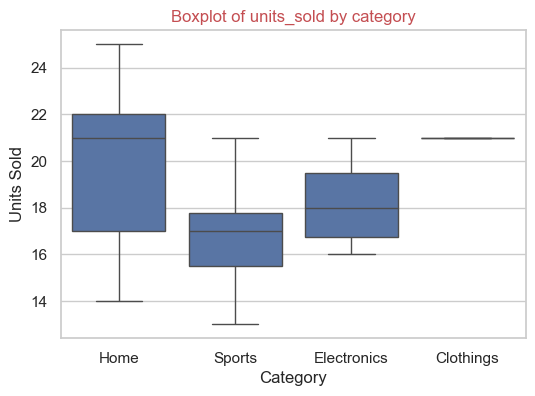

In [18]:
#Boxplot for units sold by category
plt.figure(figsize=(6,4))
sns.boxplot(x="category",y="units_sold",data=sales_data)
plt.title("Boxplot of units_sold by category",c="r")
plt.xlabel("Category")
plt.ylabel("Units Sold")

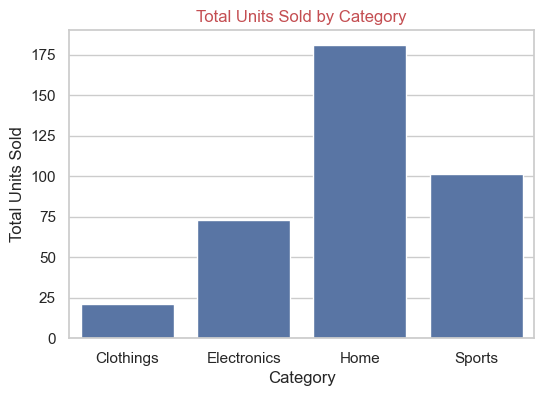

In [22]:
# Barplot for total units sold by category
plt.figure(figsize=(6, 4))
sns.barplot(x='Category', y='Total Sum', data=category_stats)
plt.title('Total Units Sold by Category',c="r")
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.show()